# Meat Database Exploration

This notebook explores the processed meat shelf-life database (`meat_shelf_life_long.csv`). The analysis covers:

- **Descriptive distributions**: indicator categories, ingredient frequencies, treatment methods, and meat types.
- **Ingredient-level analysis**: occurrence ranking, immersion time, prevalence across meat types and treatments, and chi-square association tests.
- **Efficacy analysis**: concentration–efficacy correlations, control vs. ingredient comparisons (Mann-Whitney U), and effect-size classification.
- **Stratified analysis**: meat-type-specific concentration effects, treatment rankings (Kruskal-Wallis), and best-treatment summaries.

**Prerequisites**: Run `data_processing.ipynb` first to generate `data/processed/meat_shelf_life_long.csv`.

## Table of Contents

1. [Setup](#1-setup)
2. [Descriptive Analysis](#2-descriptive-analysis)
3. [Ingredient-Level Analysis](#3-ingredient-level-analysis)
4. [Efficacy Analysis](#4-efficacy-analysis)
5. [Stratified Analysis by Meat Type](#5-stratified-analysis-by-meat-type)

## 1. Setup

### 1.1 Imports

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

### 1.2 Load Processed Data

In [194]:
df = pd.read_csv("data/processed/meat_shelf_life_long.csv")
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head()

Loaded 748 rows × 38 columns


,article_#,ingredient_id,ingredient,concentration,unit_of_concentration,normalized_concentration_%_of_meat,chemical_composition,source,immersion_time,packaging_condition,...,efficacité_pre-threshold_proximity,post-threshold_(day),post-threshold_count,efficacité_of_post-threshold,efficiency,post_inhibition_factor,post-threshold_proximity_index_1(tpi),post-threshold_proximity_index_2(tpi),efficacité_post-threshols_proximity,data_source
0,anm-0064,1,control,0.0,% (w/w),0.0,none,none,NaN,NaN,...,3.0,2,8.7,1.0,1.208,5.1,1.74,1.243,2,theoretical
1,anm-0064,1,anodic nacl solution,1.0,% (w/w),1.0,mineral,other natural sources,NaN,NaN,...,3.0,2,7.6,2.0,1.727,5.4,1.52,1.086,2,theoretical
2,anm-0064,1,anodic nacl solution,1.0,% (w/w),1.0,mineral,other natural sources,NaN,NaN,...,3.0,2,7.5,2.0,1.630,5.2,1.50,1.071,2,theoretical
3,anm-0064,1,control,0.0,% (w/w),0.0,none,none,NaN,NaN,...,3.0,2,6.4,3.0,1.231,3.8,1.28,0.914,3,theoretical
4,anm-0064,1,anodic nacl solution,1.0,% (w/w),1.0,mineral,other natural sources,NaN,NaN,...,2.0,3,7.5,2.0,0.893,1.9,1.50,1.071,2,theoretical


### 1.3 Analysis DataFrame Preparation

Create a working copy of the data, coerce numeric columns, fill categorical NaNs with `"unspecified"`, and apply consistent column aliases used throughout this notebook.

In [195]:
analysis_df = df.copy()
analysis_df = analysis_df.replace(r"^\s*$", np.nan, regex=True)

categorical_cols = [
    "treatment", "combined_treatment", "type_of_indicator",
    "ingredient", "meat_type", "part_of_product",
    "chemical_composition", "source",
]
analysis_df[categorical_cols] = analysis_df[categorical_cols].fillna("unspecified")

numeric_cols = [
    "normalized_concentration_%_of_meat",
    "initial_count",
    "lower_level_threshold_(log_cfu/g)",
    "upper_level_threshold_(log_cfu/g)",
    "pre-threshold_count",
    "post-threshold_count",
    "efficacité_pre-threshold",
    "efficacité_of_post-threshold",
    "efficiency",
    "initial_inhibition_factor",
    "pre-threshold_proximity_index_1(tpi)",
    "pre-threshold_proximity_index_2(tpi)",
    "efficacité_pre-threshold_proximity",
    "post_inhibition_factor",
    "post-threshold_proximity_index_1(tpi)",
    "post-threshold_proximity_index_2(tpi)",
    "efficacité_post-threshols_proximity",
]
for col in numeric_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df = analysis_df.rename(columns={
    "normalized_concentration_%_of_meat":   "normalized_concentration_pct",
    "efficacité_pre-threshold":             "pre_threshold_efficacy",
    "efficacité_pre-threshold_proximity":   "pre_threshold_efficacy_proximity",
    "efficacité_of_post-threshold":         "post_threshold_efficacy",
    "efficacité_post-threshols_proximity":  "post_threshold_efficacy_proximity",
})

print(f"Analysis dataframe: {len(analysis_df):,} rows × {analysis_df.shape[1]} columns")

Analysis dataframe: 748 rows × 38 columns


### 1.4 Visualization Theme and Helper Functions

In [196]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"


def make_caption(fig, text):
    fig.text(0.5, 0.01, text, ha="center", va="bottom", fontsize=10, color="dimgray")


def ci_mean(series, confidence=0.95):
    values = pd.to_numeric(series, errors="coerce").dropna()
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = values.mean()
    if n == 1:
        return mean, mean, mean
    margin = stats.t.ppf((1 + confidence) / 2.0, n - 1) * stats.sem(values)
    return mean, mean - margin, mean + margin


def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / max(1, min(k - 1, r - 1))) if n else np.nan


def kruskal_epsilon_squared(h_stat, n, k):
    return max(0, (h_stat - k + 1) / (n - k)) if n > k else np.nan


def effect_band(value, kind="correlation"):
    abs_val = abs(value)
    if kind == "correlation":
        thresholds = [(0.5, "large"), (0.3, "moderate"), (0.1, "small")]
    else:
        thresholds = [(0.14, "large"), (0.06, "moderate"), (0.01, "small")]
    for cutoff, label in thresholds:
        if abs_val >= cutoff:
            return label
    return "negligible"

## 2. Descriptive Analysis

Summarize the main categorical distributions — indicator types, ingredient frequencies, treatment methods, and meat types.

### 2.1 Indicator Category Distribution

Count rows by `type_of_indicator` to show the relative representation of microbial vs. chemical markers in the dataset.

,category,count,percentage
0,microbial,442,59.1
1,chemical,304,40.6
2,unspecified,2,0.3


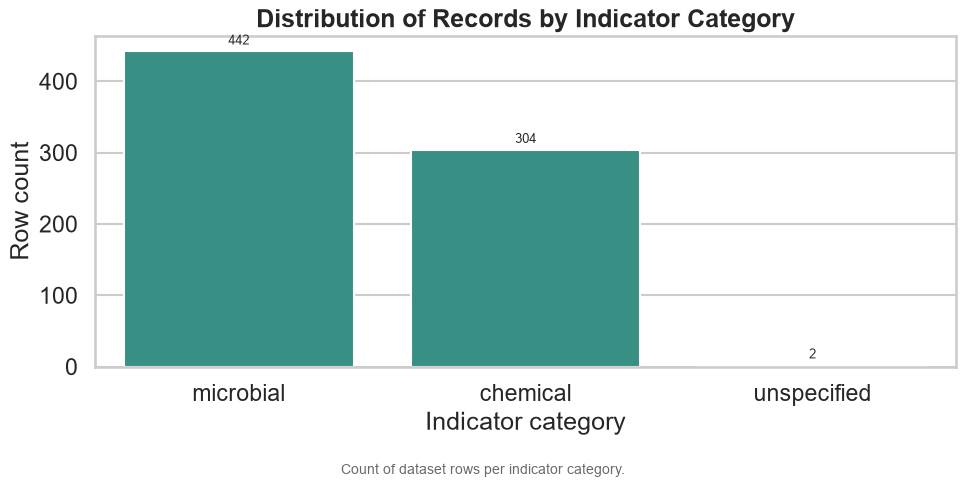

In [197]:
category_summary = (
    analysis_df["type_of_indicator"]
    .value_counts(dropna=False)
    .rename_axis("category")
    .reset_index(name="count")
)
category_summary["percentage"] = (category_summary["count"] / len(analysis_df) * 100).round(1)
display(category_summary)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=category_summary.sort_values("count", ascending=False),
    x="category", y="count", ax=ax, color="#2a9d8f",
)
ax.set_title("Distribution of Records by Indicator Category")
ax.set_xlabel("Indicator category")
ax.set_ylabel("Row count")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=9)
make_caption(fig, "Count of dataset rows per indicator category.")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 3. Ingredient-Level Analysis

Rank ingredients by occurrence, quantify immersion time, compare prevalence across meat types and treatments, and test association strength with chi-square statistics.

In [198]:
# Ingredient occurrence counts and relative frequencies
ingredient_base = analysis_df[analysis_df['ingredient'] != 'control'].copy()

def parse_immersion_time_minutes(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    extracted = pd.Series([text]).str.extract(r'(\d+(?:\.\d+)?)', expand=False).iloc[0]
    if pd.isna(extracted):
        return np.nan
    amount = float(extracted)
    if 'day' in text:
        return amount * 24 * 60
    if 'hour' in text or ' hr' in text or text.endswith('h'):
        return amount * 60
    return amount

ingredient_base['immersion_time_minutes'] = ingredient_base['immersion_time'].apply(parse_immersion_time_minutes)
ingredient_rank = (
    ingredient_base['ingredient']
    .value_counts(dropna=False)
    .rename_axis('ingredient')
    .reset_index(name='count')
)
ingredient_rank['relative_frequency_%'] = ingredient_rank['count'] / len(ingredient_base) * 100
display(ingredient_rank.head(25))


,ingredient,count,relative_frequency_%
0,nisin,42,7.894737
1,edta,32,6.015038
2,chitosan,30,5.639098
3,pomegranate fruit juice,24,4.511278
4,thyme leaves extract,24,4.511278
5,anodic nacl solution,16,3.007519
6,oregano eo,15,2.819549
7,so2,12,2.255639
8,thyme oil,12,2.255639
9,carvacrol eo,12,2.255639


### 3.1 Immersion Time Summary

Summarize mean and median immersion time per ingredient. Control rows are excluded from all ingredient-level tables.

In [199]:
ingredient_immersion = (
    ingredient_base.groupby('ingredient')
    .agg(
        count=('ingredient', 'size'),
        mean_immersion_time_minutes=('immersion_time_minutes', 'mean'),
        median_immersion_time_minutes=('immersion_time_minutes', 'median'),
    )
    .reset_index()
    .merge(ingredient_rank[['ingredient', 'relative_frequency_%']], on='ingredient', how='left')
    .sort_values(['count', 'mean_immersion_time_minutes'], ascending=[False, False])
)
display(ingredient_immersion.head(25))


,ingredient,count,mean_immersion_time_minutes,median_immersion_time_minutes,relative_frequency_%
48,nisin,42,30.0,30.0,7.894737
22,edta,32,30.0,30.0,6.015038
12,chitosan,30,2.0,2.0,5.639098
58,pomegranate fruit juice,24,2.0,2.0,4.511278
89,thyme leaves extract,24,NaN,NaN,4.511278
2,anodic nacl solution,16,NaN,NaN,3.007519
53,oregano eo,15,2.0,2.0,2.819549
97,zataria multiflora essential oil,12,2.0,2.0,2.255639
10,carvacrol eo,12,NaN,NaN,2.255639
76,so2,12,NaN,NaN,2.255639


### 3.2 Top Ingredient Immersion Time

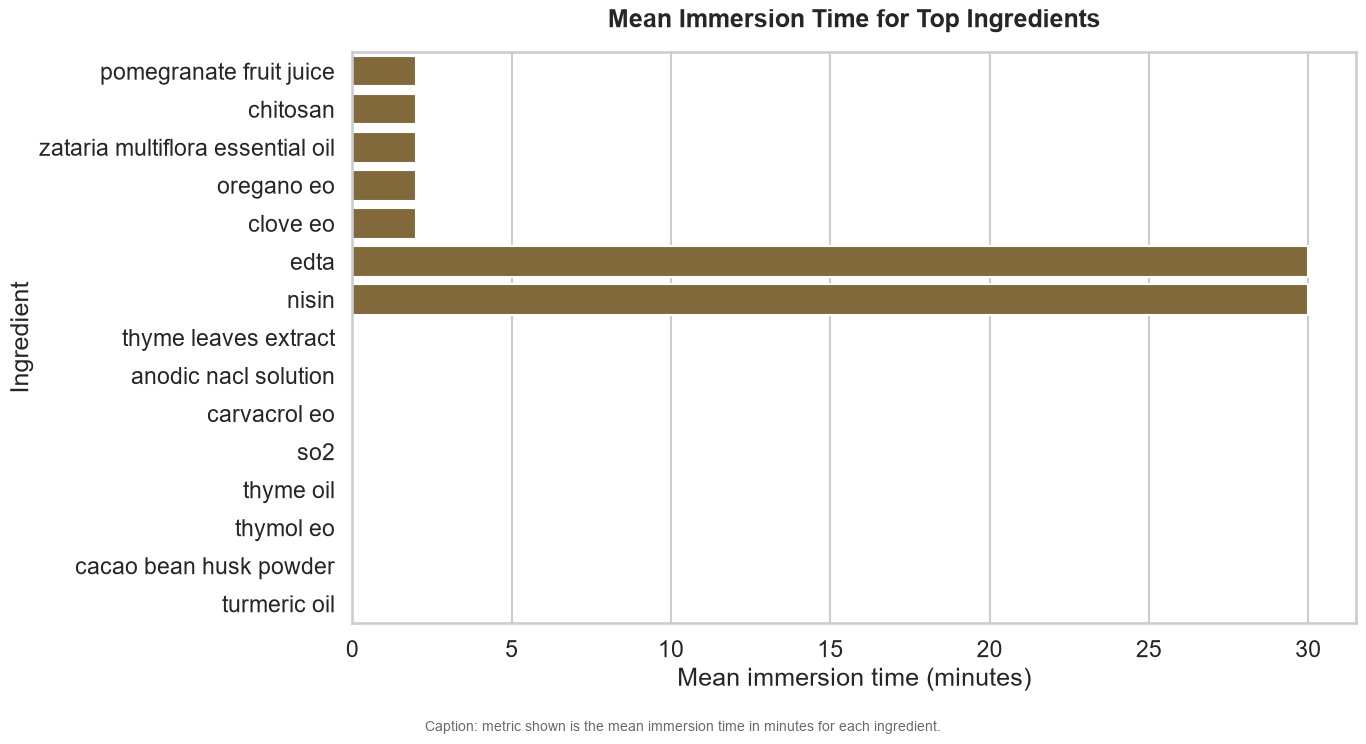

In [200]:
fig, ax = plt.subplots(figsize=(14, 8))
top_immersion = ingredient_immersion.head(15).sort_values('mean_immersion_time_minutes', ascending=True)
sns.barplot(data=top_immersion, y='ingredient', x='mean_immersion_time_minutes', ax=ax, color='#8c6d31')
ax.set_title('Mean Immersion Time for Top Ingredients', pad=18)
ax.set_xlabel('Mean immersion time (minutes)')
ax.set_ylabel('Ingredient')
make_caption(fig, 'Caption: metric shown is the mean immersion time in minutes for each ingredient.')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 3.3 Ingredient Occurrence by Ingredient Slot

Show how often each ingredient appears in each slot (`ingredient_id` 1–4).

In [201]:
ingredient_by_id = (
    ingredient_base.groupby(['ingredient_id', 'ingredient'])
    .size()
    .reset_index(name='count')
    .sort_values(['ingredient_id', 'count', 'ingredient'], ascending=[True, False, True])
)
ingredient_by_id['relative_frequency_within_ingredient_id_%'] = (
    ingredient_by_id['count']
    / ingredient_by_id.groupby('ingredient_id')['count'].transform('sum')
    * 100
)
ingredient_by_id = ingredient_by_id.merge(
    ingredient_base.groupby(['ingredient_id', 'ingredient'])['immersion_time_minutes']
    .agg(mean_immersion_time_minutes='mean', median_immersion_time_minutes='median')
    .reset_index(),
    on=['ingredient_id', 'ingredient'],
    how='left'
)

### 3.4 Prevalence Heatmaps

Within-group percentage of rows containing each of the top 15 ingredients, broken down by meat type (left) and treatment method (right).

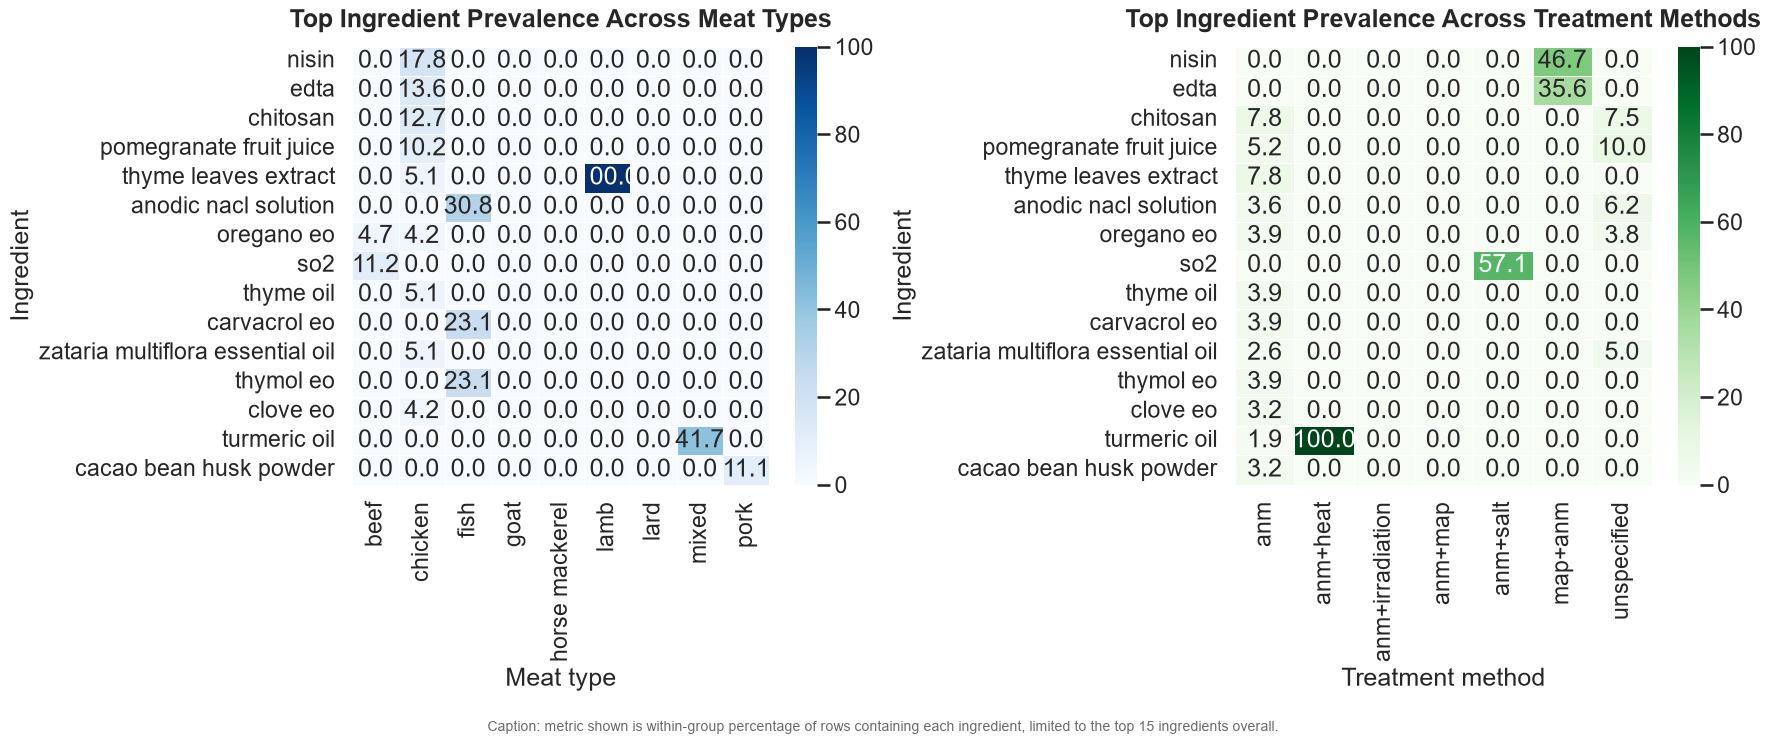

In [202]:
top_ingredients = ingredient_rank.head(15)['ingredient'].tolist()
meat_pivot = pd.crosstab(ingredient_base['ingredient'], ingredient_base['meat_type'])
treatment_pivot = pd.crosstab(ingredient_base['ingredient'], ingredient_base['treatment'])
meat_top_pct = meat_pivot.loc[top_ingredients].div(meat_pivot.sum(axis=0), axis=1) * 100
treatment_top_pct = treatment_pivot.loc[top_ingredients].div(treatment_pivot.sum(axis=0), axis=1) * 100
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(meat_top_pct, cmap='Blues', linewidths=0.5, annot=True, fmt='.1f', ax=axes[0])
axes[0].set_title('Top Ingredient Prevalence Across Meat Types', pad=14)
axes[0].set_xlabel('Meat type')
axes[0].set_ylabel('Ingredient')
sns.heatmap(treatment_top_pct, cmap='Greens', linewidths=0.5, annot=True, fmt='.1f', ax=axes[1])
axes[1].set_title('Top Ingredient Prevalence Across Treatment Methods', pad=14)
axes[1].set_xlabel('Treatment method')
axes[1].set_ylabel('Ingredient')
make_caption(fig, 'Caption: metric shown is within-group percentage of rows containing each ingredient, limited to the top 15 ingredients overall.')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 3.5 Ingredient Association Tests

Chi-square tests with Cramér's V to measure how strongly the top 15 ingredients are associated with meat type and treatment method.

In [203]:
ingredient_base['ingredient_top_group'] = ingredient_base['ingredient'].where(ingredient_base['ingredient'].isin(top_ingredients), 'other')
contingency_meat = pd.crosstab(ingredient_base['ingredient_top_group'], ingredient_base['meat_type'])
contingency_treatment = pd.crosstab(ingredient_base['ingredient_top_group'], ingredient_base['treatment'])
chi2_meat, p_meat, dof_meat, expected_meat = stats.chi2_contingency(contingency_meat)
chi2_treatment, p_treatment, dof_treatment, expected_treatment = stats.chi2_contingency(contingency_treatment)
chi_square_results = pd.DataFrame([
    {
        'comparison': 'Top ingredients vs meat_type',
        'chi2': chi2_meat,
        'dof': dof_meat,
        'p_value': p_meat,
        'cramers_v': cramers_v(contingency_meat),
        'indicator': 'ingredient prevalence'
    },
    {
        'comparison': 'Top ingredients vs treatment',
        'chi2': chi2_treatment,
        'dof': dof_treatment,
        'p_value': p_treatment,
        'cramers_v': cramers_v(contingency_treatment),
        'indicator': 'ingredient prevalence'
    }
])
display(chi_square_results)


,comparison,chi2,dof,p_value,cramers_v,indicator
0,Top ingredients vs meat_type,1255.850798,120,1.874086e-188,0.543211,ingredient prevalence
1,Top ingredients vs treatment,1004.998445,90,1.707752e-154,0.561114,ingredient prevalence


## 4. Efficacy Analysis

Examine the relationship between normalized concentration and efficacy proximity metrics, compare ingredient groups against controls, and quantify effect sizes.

### 4.1 Concentration–Efficacy Correlations

Test whether normalized ingredient concentration predicts pre- and post-threshold efficacy proximity using Pearson and Spearman correlations, with bootstrapped 95% confidence intervals.

In [204]:
analysis_df["ingredient_top_group"] = analysis_df["ingredient"].where(
    analysis_df["ingredient"].isin(top_ingredients), "other"
)

EFFICACY_METRICS = [
    "pre_threshold_efficacy_proximity",
    "post_threshold_efficacy_proximity",
]


def bootstrap_corr_ci(x, y, method="spearman", n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return np.nan, np.nan
    corr_fn = stats.pearsonr if method == "pearson" else stats.spearmanr
    estimates = [
        corr_fn(x[idx := rng.integers(0, len(x), len(x))], y[idx]).statistic
        for _ in range(n_boot)
    ]
    estimates = [e for e in estimates if np.isfinite(e)]
    return tuple(np.nanpercentile(estimates, [2.5, 97.5])) if estimates else (np.nan, np.nan)

In [205]:
correlation_rows = []

for metric in EFFICACY_METRICS:
    subset = analysis_df[["normalized_concentration_pct", metric]].dropna()
    if subset["normalized_concentration_pct"].nunique() < 2 or subset[metric].nunique() < 2:
        continue

    for method in ("pearson", "spearman"):
        corr_fn = stats.pearsonr if method == "pearson" else stats.spearmanr
        result = corr_fn(subset["normalized_concentration_pct"], subset[metric])
        ci = bootstrap_corr_ci(subset["normalized_concentration_pct"], subset[metric], method=method)
        correlation_rows.append({
            "metric":                 metric,
            "test":                   method,
            "coefficient":            result.statistic,
            "ci_low":                 ci[0],
            "ci_high":                ci[1],
            "p_value":                result.pvalue,
            "effect_size":            abs(result.statistic),
            "practical_significance": effect_band(result.statistic, "correlation"),
        })

correlation_table = pd.DataFrame(correlation_rows).sort_values(["metric", "test"])
display(correlation_table)

,metric,test,coefficient,ci_low,ci_high,p_value,effect_size,practical_significance
2,post_threshold_efficacy_proximity,pearson,-0.070319,-0.165405,0.024940,0.205395,0.070319,negligible
3,post_threshold_efficacy_proximity,spearman,-0.097958,-0.193844,0.005712,0.077373,0.097958,negligible
0,pre_threshold_efficacy_proximity,pearson,-0.074409,-0.133522,-0.004469,0.057187,0.074409,negligible
1,pre_threshold_efficacy_proximity,spearman,-0.081199,-0.154370,-0.004199,0.037894,0.081199,negligible


### 4.2 Control vs Ingredient Comparison

For each meat type, compare each active ingredient against the corresponding control group using Mann-Whitney U tests. Effect size is reported as rank-biserial correlation.

In [206]:
control_vs_ingredient_rows = []

for meat_name, meat_group in analysis_df.groupby("meat_type"):
    control_group = meat_group[meat_group["ingredient"].str.lower() == "control"]

    for ingredient_name, ingredient_group in meat_group.groupby("ingredient"):
        if ingredient_name.lower() == "control":
            continue

        for metric in EFFICACY_METRICS:
            control_vals = control_group[metric].dropna()
            ingred_vals = ingredient_group[metric].dropna()

            if len(control_vals) < 3 or len(ingred_vals) < 3:
                continue

            ctrl_mean, ctrl_ci_low, ctrl_ci_high = ci_mean(control_vals)
            ing_mean, ing_ci_low, ing_ci_high = ci_mean(ingred_vals)

            u_stat, p_val = stats.mannwhitneyu(control_vals, ingred_vals, alternative="two-sided")
            rank_biserial = 1 - (2 * u_stat) / (len(control_vals) * len(ingred_vals))

            control_vs_ingredient_rows.append({
                "meat_type":              meat_name,
                "ingredient":             ingredient_name,
                "metric":                 metric,
                "control_n":              len(control_vals),
                "ingredient_n":           len(ingred_vals),
                "control_mean":           ctrl_mean,
                "control_ci_low":         ctrl_ci_low,
                "control_ci_high":        ctrl_ci_high,
                "ingredient_mean":        ing_mean,
                "ingredient_ci_low":      ing_ci_low,
                "ingredient_ci_high":     ing_ci_high,
                "u_statistic":            u_stat,
                "p_value":                p_val,
                "rank_biserial_r":        rank_biserial,
                "effect_size":            abs(rank_biserial),
                "practical_significance": effect_band(rank_biserial, "correlation"),
            })

control_vs_ingredient_table = (
    pd.DataFrame(control_vs_ingredient_rows)
      .sort_values(["metric", "meat_type", "ingredient"])
      .reset_index(drop=True)
)
display(control_vs_ingredient_table)

,meat_type,ingredient,metric,control_n,ingredient_n,control_mean,control_ci_low,control_ci_high,ingredient_mean,ingredient_ci_low,ingredient_ci_high,u_statistic,p_value,rank_biserial_r,effect_size,practical_significance
0,beef,na2edta,post_threshold_efficacy_proximity,17,5,2.000000,1.742924,2.257076,2.000000,2.000000,2.000000,42.5,1.000000,0.000000,0.000000,negligible
1,beef,oregano eo,post_threshold_efficacy_proximity,17,3,2.000000,1.742924,2.257076,2.000000,2.000000,2.000000,25.5,1.000000,0.000000,0.000000,negligible
2,beef,α-tocopherol,post_threshold_efficacy_proximity,17,3,2.000000,1.742924,2.257076,2.000000,2.000000,2.000000,25.5,1.000000,0.000000,0.000000,negligible
3,chicken,chitosan,post_threshold_efficacy_proximity,59,13,2.220339,2.101134,2.339544,1.923077,1.755476,2.090678,490.5,0.030965,-0.279009,0.279009,small
4,chicken,clove eo,post_threshold_efficacy_proximity,59,3,2.220339,2.101134,2.339544,2.000000,2.000000,2.000000,108.0,0.401941,-0.220339,0.220339,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,pork,grape pomace extract 1,pre_threshold_efficacy_proximity,23,4,2.652174,2.441586,2.862762,2.250000,1.454388,3.045612,64.5,0.149140,-0.402174,0.402174,moderate
65,pork,grape pomace extract 2,pre_threshold_efficacy_proximity,23,4,2.652174,2.441586,2.862762,2.250000,1.454388,3.045612,64.5,0.149140,-0.402174,0.402174,moderate
66,pork,lutein,pre_threshold_efficacy_proximity,23,6,2.652174,2.441586,2.862762,2.666667,2.124740,3.208593,68.0,0.973931,0.014493,0.014493,negligible
67,pork,olive leaf,pre_threshold_efficacy_proximity,23,6,2.652174,2.441586,2.862762,2.666667,2.124740,3.208593,68.0,0.973931,0.014493,0.014493,negligible


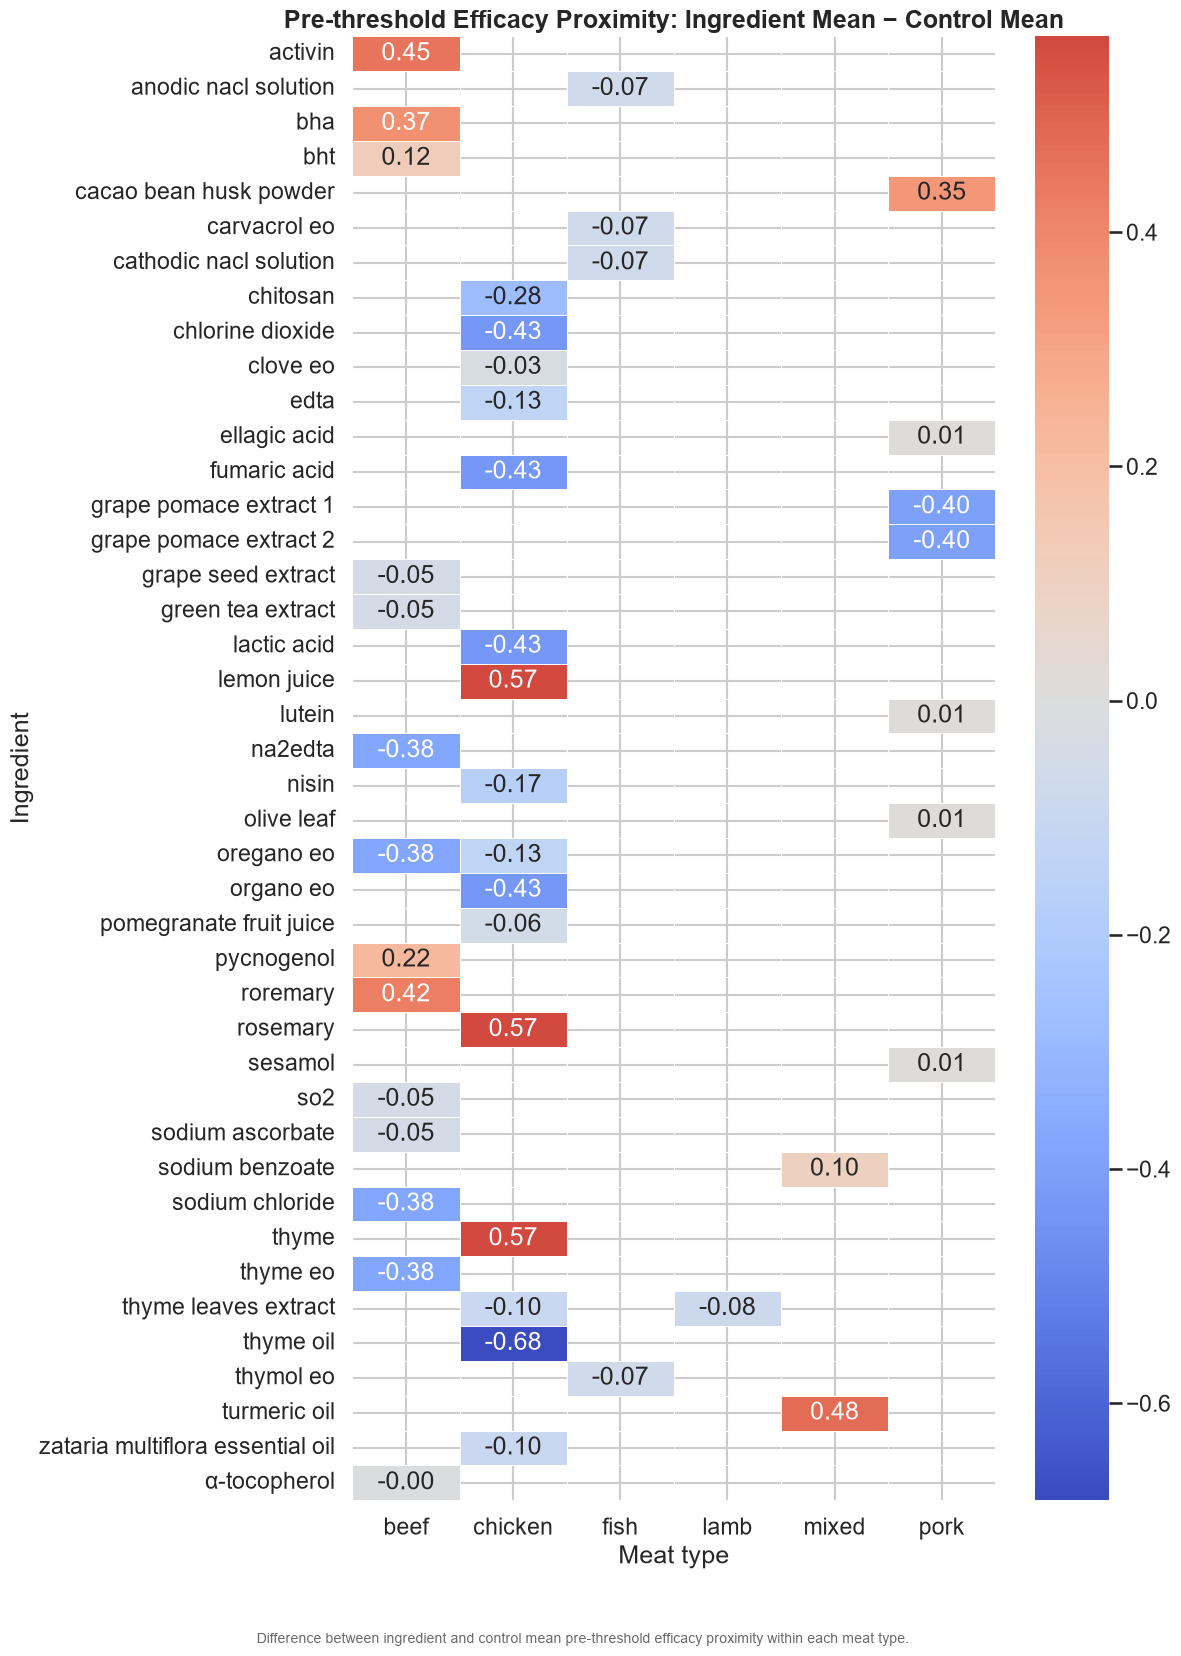

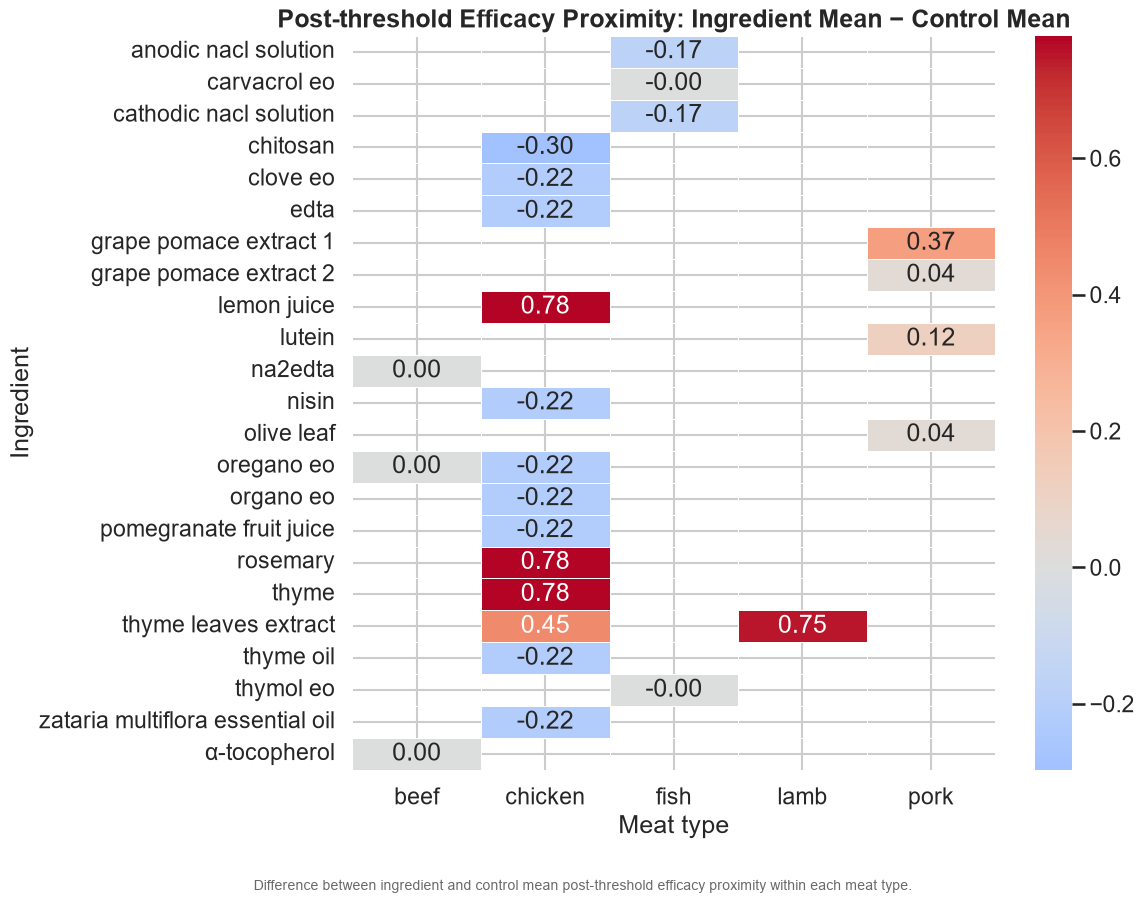

In [207]:
METRIC_LABELS = {
    "pre_threshold_efficacy_proximity":  "Pre-threshold Efficacy Proximity",
    "post_threshold_efficacy_proximity": "Post-threshold Efficacy Proximity",
}

for metric, metric_label in METRIC_LABELS.items():
    summary = (
        control_vs_ingredient_table
        .query("metric == @metric")
        .assign(mean_difference=lambda x: x["ingredient_mean"] - x["control_mean"])
        .pivot(index="ingredient", columns="meat_type", values="mean_difference")
    )

    fig, ax = plt.subplots(figsize=(12, max(6, len(summary) * 0.4)))
    sns.heatmap(summary, annot=True, fmt=".2f", center=0, cmap="coolwarm", linewidths=0.5, ax=ax)
    ax.set_title(f"{metric_label}: Ingredient Mean − Control Mean")
    ax.set_xlabel("Meat type")
    ax.set_ylabel("Ingredient")
    make_caption(fig, f"Difference between ingredient and control mean {metric_label.lower()} within each meat type.")
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

## 5. Stratified Analysis by Meat Type

Repeat the concentration-efficacy and treatment-effect analyses within each meat type to identify meat-specific patterns.

### 5.1 Concentration–Efficacy Correlations by Meat Type

In [208]:
meat_correlation_rows = []

for meat_name, meat_group in analysis_df.groupby("meat_type"):
    for metric in EFFICACY_METRICS:
        subset = meat_group[["normalized_concentration_pct", metric]].dropna()
        if len(subset) < 5 or subset["normalized_concentration_pct"].nunique() < 2 or subset[metric].nunique() < 2:
            continue
        for method in ("pearson", "spearman"):
            corr_fn = stats.pearsonr if method == "pearson" else stats.spearmanr
            result = corr_fn(subset["normalized_concentration_pct"], subset[metric])
            meat_correlation_rows.append({
                "meat_type":              meat_name,
                "metric":                 metric,
                "test":                   method,
                "coefficient":            result.statistic,
                "p_value":                result.pvalue,
                "effect_size":            abs(result.statistic),
                "practical_significance": effect_band(result.statistic, "correlation"),
            })

meat_correlation_table = (
    pd.DataFrame(meat_correlation_rows)
      .sort_values(["meat_type", "metric", "test"])
)
display(meat_correlation_table)

,meat_type,metric,test,coefficient,p_value,effect_size,practical_significance
2,beef,post_threshold_efficacy_proximity,pearson,0.379486,0.026860,0.379486,moderate
3,beef,post_threshold_efficacy_proximity,spearman,0.216435,0.218901,0.216435,small
0,beef,pre_threshold_efficacy_proximity,pearson,-0.225504,0.013669,0.225504,small
1,beef,pre_threshold_efficacy_proximity,spearman,-0.141540,0.124669,0.141540,small
6,chicken,post_threshold_efficacy_proximity,pearson,-0.132161,0.097861,0.132161,small
7,chicken,post_threshold_efficacy_proximity,spearman,-0.159182,0.045743,0.159182,small
4,chicken,pre_threshold_efficacy_proximity,pearson,0.039277,0.516584,0.039277,negligible
5,chicken,pre_threshold_efficacy_proximity,spearman,-0.039100,0.518474,0.039100,negligible
10,fish,post_threshold_efficacy_proximity,pearson,-0.107870,0.388625,0.107870,small
11,fish,post_threshold_efficacy_proximity,spearman,-0.110937,0.375198,0.110937,small


### 5.2 Treatment Effect Summaries and Kruskal-Wallis Tests

Mean efficacy proximity with 95% CI per treatment within each meat type, followed by Kruskal-Wallis tests to detect treatment differences.

In [209]:
treatment_summary_rows = []
kw_rows = []

for meat_name, meat_group in analysis_df.groupby("meat_type"):
    for metric in EFFICACY_METRICS:
        metric_data = meat_group[["treatment", metric]].dropna()
        if metric_data.empty:
            continue

        for treatment_name, treatment_group in metric_data.groupby("treatment"):
            mean, ci_low, ci_high = ci_mean(treatment_group[metric])
            treatment_summary_rows.append({
                "meat_type":  meat_name,
                "metric":     metric,
                "treatment":  treatment_name,
                "n":          len(treatment_group),
                "mean":       mean,
                "ci_low":     ci_low,
                "ci_high":    ci_high,
            })

        grouped_vals = [
            g[metric].dropna().to_numpy()
            for _, g in metric_data.groupby("treatment")
            if g[metric].notna().sum() >= 3
        ]
        if len(grouped_vals) >= 2:
            h_stat, p_val = stats.kruskal(*grouped_vals)
            n_total = len(metric_data)
            k_groups = len(grouped_vals)
            kw_rows.append({
                "meat_type":              meat_name,
                "metric":                 metric,
                "h_statistic":            h_stat,
                "p_value":                p_val,
                "epsilon_squared":        kruskal_epsilon_squared(h_stat, n_total, k_groups),
                "practical_significance": effect_band(
                    kruskal_epsilon_squared(h_stat, n_total, k_groups), "epsilon"
                ),
                "treatment_levels":       k_groups,
                "n":                      n_total,
            })

treatment_summary_table = (
    pd.DataFrame(treatment_summary_rows)
      .sort_values(["meat_type", "metric", "mean"], ascending=[True, True, False])
)
kw_table = pd.DataFrame(kw_rows).sort_values(["metric", "p_value"])

print("Treatment means with 95% CI:")
display(treatment_summary_table)
print("\nKruskal-Wallis tests (treatment differences within each meat type):")
display(kw_table)

Treatment means with 95% CI:


,meat_type,metric,treatment,n,mean,ci_low,ci_high
4,beef,post_threshold_efficacy_proximity,anm,15,2.133333,1.938477,2.328190
5,beef,post_threshold_efficacy_proximity,unspecified,24,2.000000,1.823904,2.176096
0,beef,pre_threshold_efficacy_proximity,anm,40,2.475000,2.313258,2.636742
3,beef,pre_threshold_efficacy_proximity,unspecified,58,2.379310,2.241512,2.517108
2,beef,pre_threshold_efficacy_proximity,anm+salt,21,2.333333,2.113453,2.553213
1,beef,pre_threshold_efficacy_proximity,anm+map,4,2.000000,2.000000,2.000000
12,chicken,post_threshold_efficacy_proximity,anm+irradiation,6,3.000000,3.000000,3.000000
15,chicken,post_threshold_efficacy_proximity,unspecified,48,2.270833,2.127331,2.414335
11,chicken,post_threshold_efficacy_proximity,anm,48,2.125000,2.010956,2.239044
13,chicken,post_threshold_efficacy_proximity,anm+map,1,2.000000,2.000000,2.000000



Kruskal-Wallis tests (treatment differences within each meat type):


,meat_type,metric,h_statistic,p_value,epsilon_squared,practical_significance,treatment_levels,n
3,chicken,post_threshold_efficacy_proximity,40.505145,8.326552e-09,0.243540,large,4,158
7,lamb,post_threshold_efficacy_proximity,5.250000,2.194677e-02,0.326923,large,2,15
5,fish,post_threshold_efficacy_proximity,3.740281,5.311551e-02,0.042817,small,2,66
1,beef,post_threshold_efficacy_proximity,1.025723,3.111654e-01,0.000695,negligible,2,39
10,pork,post_threshold_efficacy_proximity,0.052220,9.742278e-01,0.000000,negligible,3,53
2,chicken,pre_threshold_efficacy_proximity,23.180913,3.702409e-05,0.074468,moderate,4,275
4,fish,pre_threshold_efficacy_proximity,3.097357,7.841952e-02,0.021622,small,2,99
8,mixed,pre_threshold_efficacy_proximity,2.052503,1.519562e-01,0.042100,small,2,27
0,beef,pre_threshold_efficacy_proximity,3.878934,2.748374e-01,0.007386,negligible,4,123
9,pork,pre_threshold_efficacy_proximity,3.066565,3.814756e-01,0.000653,negligible,4,106


### 5.3 Mean Efficacy by Meat Type and Treatment

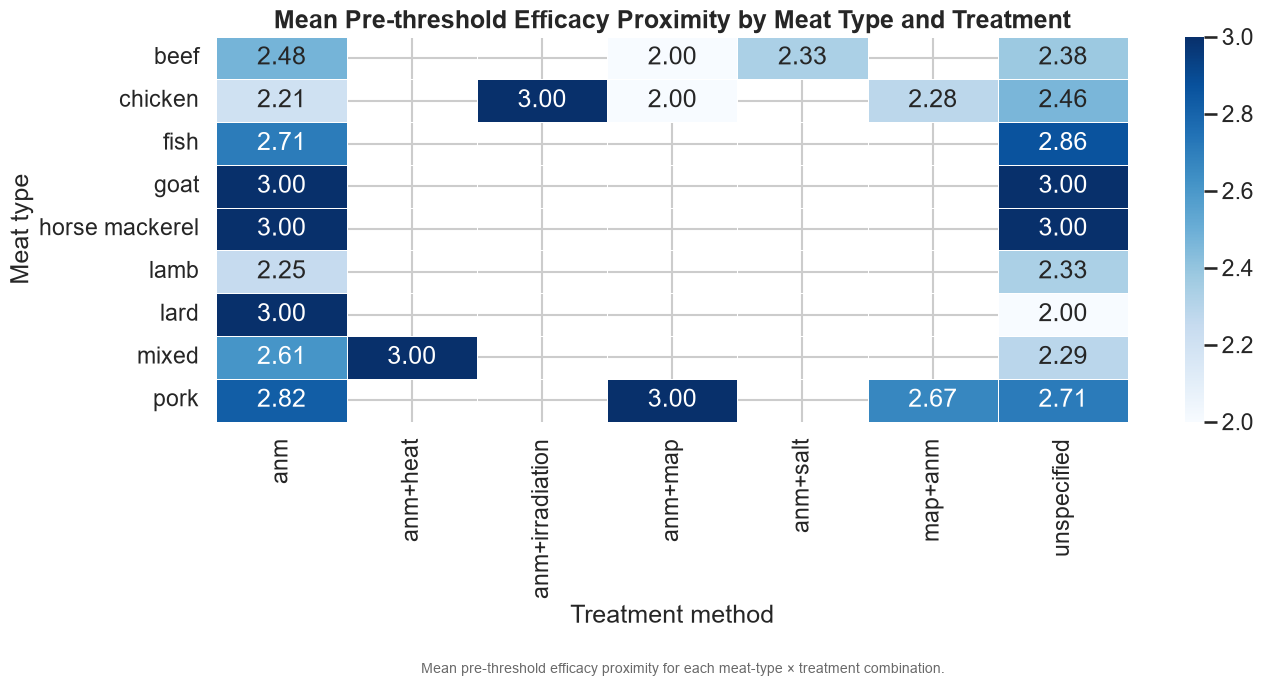

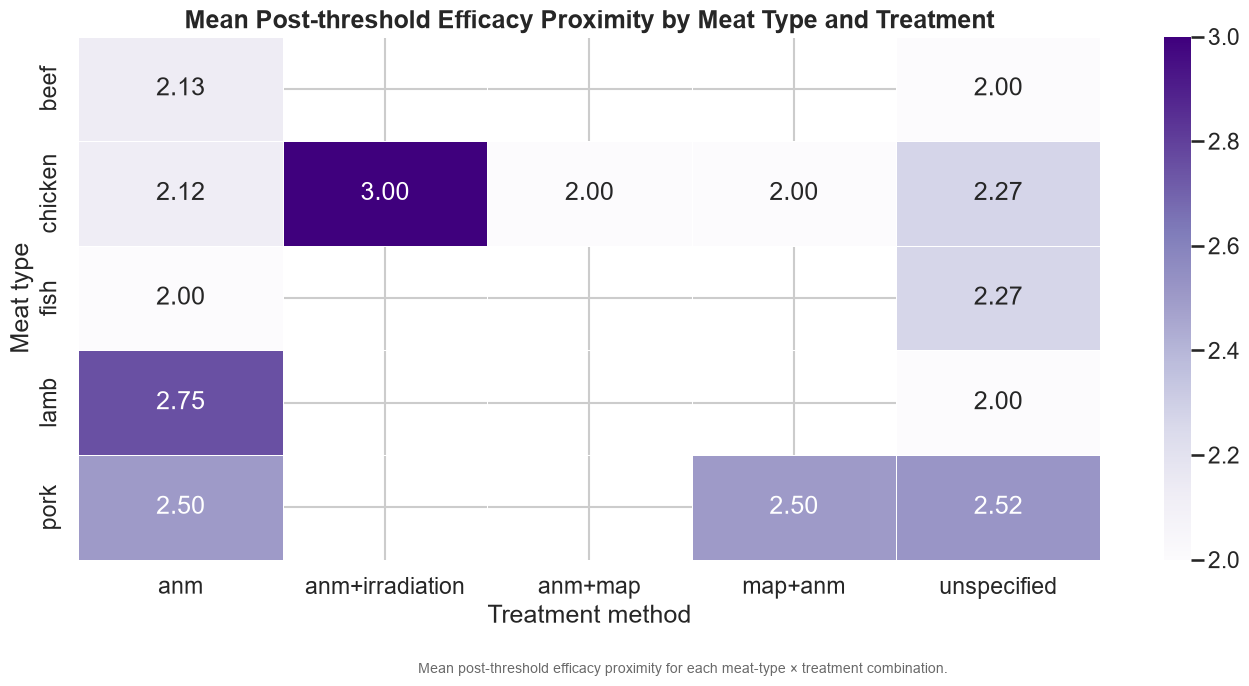

In [210]:
cmaps = {"pre_threshold_efficacy_proximity": "Blues", "post_threshold_efficacy_proximity": "Purples"}

for metric, metric_label in METRIC_LABELS.items():
    pivot = analysis_df.pivot_table(
        index="meat_type", columns="treatment", values=metric, aggfunc="mean"
    )
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmaps[metric], linewidths=0.5, ax=ax)
    ax.set_title(f"Mean {metric_label} by Meat Type and Treatment")
    ax.set_xlabel("Treatment method")
    ax.set_ylabel("Meat type")
    make_caption(fig, f"Mean {metric_label.lower()} for each meat-type × treatment combination.")
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

### 5.4 Best and Worst Treatment by Meat Type

In [211]:
best_treatment_rows = []

for meat_name, meat_group in analysis_df.groupby("meat_type"):
    for metric in EFFICACY_METRICS:
        summaries = [
            (t_name, *ci_mean(t_group[metric]), t_group[metric].notna().sum())
            for t_name, t_group in meat_group[["treatment", metric]].dropna().groupby("treatment")
        ]
        if not summaries:
            continue
        best  = max(summaries, key=lambda r: r[1])
        worst = min(summaries, key=lambda r: r[1])
        best_treatment_rows.append({
            "meat_type":      meat_name,
            "metric":         metric,
            "best_treatment": best[0],
            "best_mean":      best[1],
            "best_ci_low":    best[2],
            "best_ci_high":   best[3],
            "worst_treatment": worst[0],
            "worst_mean":     worst[1],
            "worst_ci_low":   worst[2],
            "worst_ci_high":  worst[3],
        })

display(pd.DataFrame(best_treatment_rows))

,meat_type,metric,best_treatment,best_mean,best_ci_low,best_ci_high,worst_treatment,worst_mean,worst_ci_low,worst_ci_high
0,beef,pre_threshold_efficacy_proximity,anm,2.475000,2.313258,2.636742,anm+map,2.000000,2.000000,2.000000
1,beef,post_threshold_efficacy_proximity,anm,2.133333,1.938477,2.328190,unspecified,2.000000,1.823904,2.176096
2,chicken,pre_threshold_efficacy_proximity,anm+irradiation,3.000000,3.000000,3.000000,anm+map,2.000000,2.000000,2.000000
3,chicken,post_threshold_efficacy_proximity,anm+irradiation,3.000000,3.000000,3.000000,anm+map,2.000000,2.000000,2.000000
4,fish,pre_threshold_efficacy_proximity,unspecified,2.864865,2.749308,2.980422,anm,2.709677,2.593465,2.825890
5,fish,post_threshold_efficacy_proximity,unspecified,2.266667,2.008459,2.524874,anm,2.000000,1.838237,2.161763
6,goat,pre_threshold_efficacy_proximity,anm,3.000000,3.000000,3.000000,anm,3.000000,3.000000,3.000000
7,horse mackerel,pre_threshold_efficacy_proximity,anm,3.000000,3.000000,3.000000,anm,3.000000,3.000000,3.000000
8,lamb,pre_threshold_efficacy_proximity,unspecified,2.333333,0.899116,3.767551,anm,2.250000,1.962643,2.537357
9,lamb,post_threshold_efficacy_proximity,anm,2.750000,2.462643,3.037357,unspecified,2.000000,2.000000,2.000000
